# Corruption Failure Analysis

목적: MVTec, VisA, BTAD를 하나의 industrial AD benchmark로 보고, clean 대비 corruption 후 성능이 어디서/어떻게 무너지는지 핵심만 확인한다.

이 노트북에서 보는 것:

1. 전체 benchmark의 clean vs corruption drop
2. easy / normal / hard split별 robustness 차이
3. hard target class의 class-level metric drop
4. image-level anomaly score collapse
5. pixel-wise heatmap failure case

핵심 해석 기준:

- `P-AUROC_drop`: pixel localization ranking이 얼마나 무너졌는지
- `P-AP_drop`: defect pixel이 희소한 상황에서 precision-recall이 얼마나 무너졌는지
- `fp_shift`: normal image anomaly score가 corruption 후 얼마나 올라갔는지
- `fn_shift`: anomaly image anomaly score가 corruption 후 얼마나 내려갔는지
- `gap_collapse`: anomaly-normal score gap이 얼마나 줄었는지

In [123]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)

def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / 'results').exists() or (candidate / '.git').exists():
            return candidate
    return start

ROOT = find_repo_root()
BENCH_ROOT = ROOT / 'results' / 'corruption_benchmark'
TARGET_ROOT = ROOT / 'results' / 'target_failure_analysis'
SUMMARY_ROOT = TARGET_ROOT / 'summaries'

MAIN_METRICS = ['I-AUROC', 'P-AUROC', 'P-AP', 'P-F1max']
PIXEL_METRICS = ['P-AUROC', 'P-AP', 'P-F1max']

def condition_to_corruption(condition):
    if condition == 'clean':
        return 'clean', 0
    if condition.endswith('_s3'):
        return condition[:-3], 3
    return condition, np.nan

def show(df, n=20):
    display(df.head(n).style.format(precision=3))

print('Benchmark root:', BENCH_ROOT.exists(), BENCH_ROOT)
print('Target root:', TARGET_ROOT.exists(), TARGET_ROOT)

Benchmark root: True /Users/taehayeong/Desktop/Git_workspace/AdaptCLIP/results/corruption_benchmark
Target root: True /Users/taehayeong/Desktop/Git_workspace/AdaptCLIP/results/target_failure_analysis


## 1. Load Full Benchmark Metrics

`results/corruption_benchmark` 안의 `class_metrics_*.csv`를 모두 읽는다. 여기서는 불필요한 컬럼을 만들지 않고, 파일 경로에서 `model / dataset / split / condition`만 붙인다.

In [124]:
def load_benchmark_metrics(root=BENCH_ROOT):
    rows = []
    for path in root.glob('*/*/*/*/class_metrics_*.csv'):
        rel = path.relative_to(root).parts
        model, dataset, split, condition = rel[:4]
        df = pd.read_csv(path)
        df['model'] = model
        df['dataset'] = dataset
        df['split'] = split
        df['condition'] = condition
        corruption, severity = condition_to_corruption(condition)
        df['corruption'] = corruption
        df['severity'] = severity
        rows.append(df)
    if not rows:
        return pd.DataFrame()
    out = pd.concat(rows, ignore_index=True)
    out['class'] = out['class'].astype(str)
    cols = ['model', 'dataset', 'split', 'class', 'condition', 'corruption', 'severity'] + [m for m in MAIN_METRICS if m in out.columns]
    return out[cols]

bench = load_benchmark_metrics()
bench_class = bench[bench['class'].str.lower() != 'avg'].copy()
bench_avg = bench[bench['class'].str.lower() == 'avg'].copy()

print('class metric files loaded:', bench[['model','dataset','split','condition']].drop_duplicates().shape[0])
print('rows:', bench.shape)
show(bench.head(8), 8)

class metric files loaded: 144
rows: (1440, 11)


,model,dataset,split,class,condition,corruption,severity,I-AUROC,P-AUROC,P-AP,P-F1max
0,winclip,mvtec,easy,bottle,motion_blur_s3,motion_blur,3,0.000,0.706,0.208,0.261
1,winclip,mvtec,easy,cable,motion_blur_s3,motion_blur,3,0.000,0.609,0.062,0.119
2,winclip,mvtec,easy,capsule,motion_blur_s3,motion_blur,3,0.000,0.456,0.010,0.022
3,winclip,mvtec,easy,carpet,motion_blur_s3,motion_blur,3,0.833,0.385,0.005,0.013
4,winclip,mvtec,easy,grid,motion_blur_s3,motion_blur,3,0.000,0.426,0.007,0.017
5,winclip,mvtec,easy,hazelnut,motion_blur_s3,motion_blur,3,0.148,0.493,0.002,0.003
6,winclip,mvtec,easy,leather,motion_blur_s3,motion_blur,3,0.691,0.461,0.001,0.002
7,winclip,mvtec,easy,metal_nut,motion_blur_s3,motion_blur,3,0.000,0.227,0.009,0.031


## 2. Full Benchmark: Clean vs Corruption Drop

drop은 `clean_metric - corrupted_metric`으로 계산한다. 양수면 corruption 후 성능이 하락한 것이다.

주의: split별 class subset은 normal/anomaly가 한쪽으로 몰릴 수 있어서 `I-AUROC`가 0 또는 100으로 튈 수 있다. split 해석은 `P-AUROC`, `P-AP`, `P-F1max`를 우선한다.

In [125]:
def compute_drops(df, keys):
    clean = df[df['condition'] == 'clean'][keys + MAIN_METRICS].copy()
    clean = clean.rename(columns={m: f'clean_{m}' for m in MAIN_METRICS})
    corr = df[df['condition'] != 'clean'].copy()
    merged = corr.merge(clean, on=keys, how='left')
    for m in MAIN_METRICS:
        if m in merged and f'clean_{m}' in merged:
            merged[f'{m}_drop'] = merged[f'clean_{m}'] - merged[m]
    return merged

drop_class = compute_drops(bench_class, ['model', 'dataset', 'split', 'class'])

split_drop = (
    drop_class
    .groupby(['model', 'split', 'corruption'], as_index=False)[[f'{m}_drop' for m in PIXEL_METRICS]]
    .mean()
    .sort_values(['split', 'P-AP_drop'], ascending=[True, False])
)

show(split_drop, 20)

,model,split,corruption,P-AUROC_drop,P-AP_drop,P-F1max_drop
14,anomalyclip,all,motion_blur,0.044,0.053,0.044
2,adaptclip,all,motion_blur,0.010,0.032,0.038
13,anomalyclip,all,gaussian_noise,0.012,0.032,0.033
1,adaptclip,all,gaussian_noise,0.010,0.021,0.026
0,adaptclip,all,brightness,0.001,0.001,0.001
12,anomalyclip,all,brightness,0.009,0.001,-0.001
24,winclip,all,brightness,0.044,-0.001,-0.001
25,winclip,all,gaussian_noise,-0.047,-0.002,-0.004
26,winclip,all,motion_blur,0.029,-0.002,-0.002
17,anomalyclip,easy,motion_blur,0.046,0.086,0.073


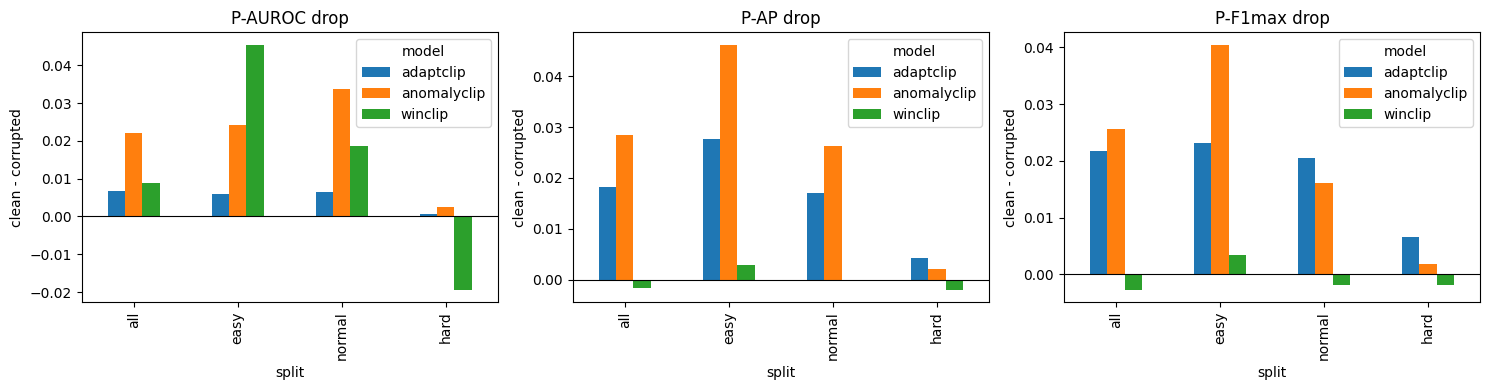

In [126]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, metric in zip(axes, PIXEL_METRICS):
    pivot = split_drop.pivot_table(index='split', columns='model', values=f'{metric}_drop', aggfunc='mean')
    pivot = pivot.reindex(['all', 'easy', 'normal', 'hard'])
    pivot.plot(kind='bar', ax=ax)
    ax.set_title(f'{metric} drop')
    ax.set_xlabel('split')
    ax.set_ylabel('clean - corrupted')
    ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()

## 3. Most Corruption-Sensitive Classes

`all` split 기준으로 class-level drop이 큰 class를 본다. 논문에서는 이 표를 통해 heatmap을 왜 특정 class에서 뽑았는지 설명할 수 있다.

In [127]:
top_sensitive = (
    drop_class[drop_class['split'] == 'all']
    .loc[:, ['model', 'dataset', 'class', 'corruption', 'P-AUROC_drop', 'P-AP_drop', 'P-F1max_drop']]
    .sort_values(['P-AP_drop', 'P-AUROC_drop'], ascending=False)
)

show(top_sensitive, 25)

,model,dataset,class,corruption,P-AUROC_drop,P-AP_drop,P-F1max_drop
703,anomalyclip,btad,2,motion_blur,0.156,0.281,0.276
815,adaptclip,mvtec,hazelnut,motion_blur,0.019,0.235,0.204
830,adaptclip,mvtec,hazelnut,gaussian_noise,0.016,0.205,0.188
472,anomalyclip,mvtec,metal_nut,gaussian_noise,0.035,0.198,0.139
833,adaptclip,mvtec,pill,gaussian_noise,0.055,0.197,0.152
457,anomalyclip,mvtec,metal_nut,motion_blur,0.045,0.181,0.129
459,anomalyclip,mvtec,screw,motion_blur,0.329,0.174,0.160
973,adaptclip,visa,capsules,motion_blur,0.031,0.159,0.150
473,anomalyclip,mvtec,pill,gaussian_noise,-0.020,0.156,0.183
458,anomalyclip,mvtec,pill,motion_blur,0.040,0.153,0.150


## 4. Target Pixel-Level Metrics

여기는 hard class에서 pixel-wise localization 성능을 정리하는 부분이다. image-level score confidence와 분리해서 본다.

먼저 clean 조건의 pixel metric을 한 번만 보고, 그 다음 corruption 조건에서의 metric과 clean 대비 drop을 별도 표로 본다.

핵심 metric:

- `P-AUROC`: defect pixel과 background pixel의 ranking 분리
- `P-AP`: defect pixel이 희소할 때의 precision-recall 품질
- `P-F1max`: threshold를 최적으로 잡았을 때의 segmentation 품질


In [128]:
def load_target_class_metrics(root=TARGET_ROOT):
    rows = []
    for path in root.glob('*/*/*/*/class_metrics_*.csv'):
        rel = path.relative_to(root).parts
        model, dataset, target_class, condition = rel[:4]
        df = pd.read_csv(path)
        df['model'] = model
        df['dataset'] = dataset
        df['target_class'] = str(target_class)
        df['condition'] = condition
        corruption, severity = condition_to_corruption(condition)
        df['corruption'] = corruption
        df['severity'] = severity
        rows.append(df)
    if not rows:
        return pd.DataFrame()
    out = pd.concat(rows, ignore_index=True)
    cols = ['model', 'dataset', 'target_class', 'condition', 'corruption', 'severity'] + [m for m in MAIN_METRICS if m in out.columns]
    return out[cols]

target_metrics = load_target_class_metrics()
target_drop = compute_drops(target_metrics, ['model', 'dataset', 'target_class'])

clean_pixel_table = (
    target_metrics[target_metrics['condition'] == 'clean']
    [['model', 'dataset', 'target_class', 'P-AUROC', 'P-AP', 'P-F1max']]
    .sort_values(['model', 'dataset', 'target_class'])
    .reset_index(drop=True)
)

corruption_pixel_table = (
    target_drop[
        [
            'model', 'dataset', 'target_class', 'corruption', 'severity',
            'P-AUROC', 'P-AP', 'P-F1max',
            'P-AUROC_drop', 'P-AP_drop', 'P-F1max_drop',
        ]
    ]
    .sort_values(['model', 'dataset', 'target_class', 'corruption', 'severity'])
    .reset_index(drop=True)
)

print('target metric rows:', target_metrics.shape)
print('clean pixel metric table:')
display(clean_pixel_table.style.format(precision=3))


target metric rows: (120, 10)
clean pixel metric table:


,model,dataset,target_class,P-AUROC,P-AP,P-F1max
0,adaptclip,btad,02,0.934,0.605,0.616
1,adaptclip,mvtec,cable,0.766,0.156,0.247
2,adaptclip,mvtec,pill,0.899,0.331,0.352
3,adaptclip,mvtec,screw,0.979,0.288,0.345
4,adaptclip,mvtec,transistor,0.693,0.156,0.195
5,adaptclip,visa,cashew,0.936,0.226,0.278
6,adaptclip,visa,macaroni1,0.980,0.162,0.229
7,adaptclip,visa,macaroni2,0.982,0.022,0.064
8,adaptclip,visa,pcb2,0.929,0.124,0.201
9,adaptclip,visa,pcb3,0.880,0.047,0.106


### Corrupted Pixel-Level Metric Changes

아래 표는 corruption 조건에서의 pixel metric과 clean 대비 drop만 보여준다. clean metric은 위 표에 한 번만 두고 반복하지 않는다.

- `P-AUROC`, `P-AP`, `P-F1max`: corrupted condition에서의 pixel metric
- `*_drop`: clean metric - corrupted metric
- drop이 클수록 corruption 후 localization이 더 많이 무너진 것이다.


In [129]:
display(corruption_pixel_table.style.format(precision=3))

worst_pixel_cases = corruption_pixel_table.sort_values(
    ['P-AP_drop', 'P-AUROC_drop'],
    ascending=False,
)
show(worst_pixel_cases, 25)


,model,dataset,target_class,corruption,severity,P-AUROC,P-AP,P-F1max,P-AUROC_drop,P-AP_drop,P-F1max_drop
0,adaptclip,btad,02,brightness,3,0.934,0.597,0.603,0.001,0.007,0.013
1,adaptclip,btad,02,gaussian_noise,3,0.920,0.639,0.622,0.014,-0.034,-0.006
2,adaptclip,btad,02,motion_blur,3,0.918,0.489,0.539,0.017,0.115,0.077
3,adaptclip,mvtec,cable,brightness,3,0.791,0.173,0.263,-0.025,-0.017,-0.016
4,adaptclip,mvtec,cable,gaussian_noise,3,0.813,0.161,0.224,-0.047,-0.005,0.024
5,adaptclip,mvtec,cable,motion_blur,3,0.790,0.150,0.212,-0.024,0.006,0.036
6,adaptclip,mvtec,pill,brightness,3,0.891,0.307,0.322,0.008,0.024,0.029
7,adaptclip,mvtec,pill,gaussian_noise,3,0.841,0.133,0.196,0.058,0.198,0.155
8,adaptclip,mvtec,pill,motion_blur,3,0.879,0.249,0.301,0.021,0.082,0.051
9,adaptclip,mvtec,screw,brightness,3,0.980,0.278,0.347,-0.001,0.010,-0.003


,model,dataset,target_class,corruption,severity,P-AUROC,P-AP,P-F1max,P-AUROC_drop,P-AP_drop,P-F1max_drop
32,anomalyclip,btad,02,motion_blur,3,0.745,0.258,0.302,0.156,0.281,0.276
7,adaptclip,mvtec,pill,gaussian_noise,3,0.841,0.133,0.196,0.058,0.198,0.155
41,anomalyclip,mvtec,screw,motion_blur,3,0.618,0.091,0.173,0.329,0.174,0.160
38,anomalyclip,mvtec,pill,motion_blur,3,0.744,0.164,0.228,0.040,0.153,0.150
37,anomalyclip,mvtec,pill,gaussian_noise,3,0.818,0.167,0.207,-0.034,0.149,0.171
11,adaptclip,mvtec,screw,motion_blur,3,0.955,0.141,0.194,0.024,0.147,0.151
35,anomalyclip,mvtec,cable,motion_blur,3,0.912,0.337,0.369,0.024,0.124,0.092
2,adaptclip,btad,02,motion_blur,3,0.918,0.489,0.539,0.017,0.115,0.077
34,anomalyclip,mvtec,cable,gaussian_noise,3,0.900,0.348,0.372,0.036,0.112,0.088
8,adaptclip,mvtec,pill,motion_blur,3,0.879,0.249,0.301,0.021,0.082,0.051


## 5. Image-Level Score Confidence

여기는 교수님 질문에 가장 직접적으로 대응하는 부분이다. AUROC/AP 같은 최종 metric이 아니라, hard class에서 모델이 실제로 준 **anomaly score 자체**를 본다.

먼저 봐야 할 값은 gap이 아니라 score 자체다.

- `clean_normal_mean`: clean 정상 이미지의 평균 anomaly score
- `corrupt_normal_mean`: corrupted 정상 이미지의 평균 anomaly score
- `clean_anomaly_mean`: clean 이상 이미지의 평균 anomaly score
- `corrupt_anomaly_mean`: corrupted 이상 이미지의 평균 anomaly score

해석은 간단하다.

- 정상 score가 corruption 후 올라가면: 정상도 이상처럼 보는 false-positive confidence 증가
- 이상 score가 corruption 후 내려가면: 이상을 덜 이상하게 보는 false-negative confidence 증가
- normal/anomaly score가 가까워지면: confidence separation이 무너짐

`fp_shift`, `fn_shift`, `gap_collapse`는 위 score 변화를 한 줄로 요약하는 보조 지표로만 본다.


In [130]:
shift_path = SUMMARY_ROOT / 'target_clean_to_corruption_score_shift.csv'
raw_path = SUMMARY_ROOT / 'target_sample_scores_raw.csv'

score_shift = pd.read_csv(shift_path)
sample_scores = pd.read_csv(raw_path)

score_table = score_shift.rename(columns={
    'clean_mean_score_normal': 'clean_normal_mean',
    'mean_score_normal': 'corrupt_normal_mean',
    'clean_mean_score_anomaly': 'clean_anomaly_mean',
    'mean_score_anomaly': 'corrupt_anomaly_mean',
    'delta_mean_score_normal': 'normal_score_change',
    'delta_mean_score_anomaly': 'anomaly_score_change',
})

clean_score_table = (
    score_table[
        ['model', 'dataset', 'target_class', 'clean_normal_mean', 'clean_anomaly_mean']
    ]
    .drop_duplicates()
    .sort_values(['model', 'dataset', 'target_class'])
    .reset_index(drop=True)
)

corruption_score_table = (
    score_table[
        [
            'model', 'dataset', 'target_class', 'corruption', 'severity',
            'corrupt_normal_mean', 'corrupt_anomaly_mean',
            'normal_score_change', 'anomaly_score_change',
            'fp_shift', 'fn_shift', 'gap_collapse',
        ]
    ]
    .sort_values(['model', 'dataset', 'target_class', 'corruption', 'severity'])
    .reset_index(drop=True)
)

print('score shift rows:', score_shift.shape)
print('models:', ', '.join(sorted(clean_score_table['model'].unique())))
print('target hard classes per model:')
display(
    clean_score_table
    .groupby('model')['target_class']
    .apply(lambda x: ', '.join(sorted(map(str, x.unique()))))
    .to_frame('target_classes')
)

# Clean score table: clean condition에서 label별 anomaly score 자체를 본다.
display(clean_score_table.style.format(precision=3))


score shift rows: (90, 35)
models: adaptclip, anomalyclip, winclip
target hard classes per model:


,target_classes
model,
adaptclip,"02, cable, cashew, macaroni1, macaroni2, pcb2,..."
anomalyclip,"02, cable, cashew, macaroni1, macaroni2, pcb2,..."
winclip,"02, cable, cashew, macaroni1, macaroni2, pcb2,..."


,model,dataset,target_class,clean_normal_mean,clean_anomaly_mean
0,adaptclip,btad,02,0.517,0.735
1,adaptclip,mvtec,cable,0.825,0.858
2,adaptclip,mvtec,pill,0.470,0.689
3,adaptclip,mvtec,screw,0.812,0.868
4,adaptclip,mvtec,transistor,0.739,0.844
5,adaptclip,visa,cashew,0.363,0.597
6,adaptclip,visa,macaroni1,0.406,0.498
7,adaptclip,visa,macaroni2,0.911,0.955
8,adaptclip,visa,pcb2,0.697,0.764
9,adaptclip,visa,pcb3,0.715,0.757


### Corrupted Score Changes

아래 표는 corruption 조건에서의 score와 clean 대비 변화량만 보여준다. clean score는 위 표에 한 번만 두고, 여기서는 중복하지 않는다.

- `corrupt_normal_mean`: corrupted 정상 이미지 평균 anomaly score
- `corrupt_anomaly_mean`: corrupted 이상 이미지 평균 anomaly score
- `normal_score_change`: corrupted normal - clean normal
- `anomaly_score_change`: corrupted anomaly - clean anomaly


In [131]:
# Corruption score table: corruption별 score와 clean 대비 변화량만 본다.
display(corruption_score_table.style.format(precision=3))

# 빠르게 worst case만 보고 싶을 때 사용하는 compact ranking.
worst_score_cases = corruption_score_table.sort_values(
    ['normal_score_change', 'fn_shift', 'gap_collapse'],
    ascending=False,
)
show(worst_score_cases, 25)


,model,dataset,target_class,corruption,severity,corrupt_normal_mean,corrupt_anomaly_mean,normal_score_change,anomaly_score_change,fp_shift,fn_shift,gap_collapse
0,adaptclip,btad,02,brightness,3,0.387,0.663,-0.129,-0.072,-0.129,0.072,-0.057
1,adaptclip,btad,02,gaussian_noise,3,0.532,0.721,0.016,-0.014,0.016,0.014,0.030
2,adaptclip,btad,02,motion_blur,3,0.461,0.622,-0.055,-0.113,-0.055,0.113,0.058
3,adaptclip,mvtec,cable,brightness,3,0.801,0.837,-0.024,-0.021,-0.024,0.021,-0.003
4,adaptclip,mvtec,cable,gaussian_noise,3,0.838,0.864,0.012,0.006,0.012,-0.006,0.006
5,adaptclip,mvtec,cable,motion_blur,3,0.834,0.874,0.008,0.016,0.008,-0.016,-0.008
6,adaptclip,mvtec,pill,brightness,3,0.342,0.529,-0.128,-0.160,-0.128,0.160,0.032
7,adaptclip,mvtec,pill,gaussian_noise,3,0.652,0.732,0.182,0.043,0.182,-0.043,0.139
8,adaptclip,mvtec,pill,motion_blur,3,0.351,0.456,-0.119,-0.233,-0.119,0.233,0.113
9,adaptclip,mvtec,screw,brightness,3,0.777,0.847,-0.035,-0.021,-0.035,0.021,-0.014


,model,dataset,target_class,corruption,severity,corrupt_normal_mean,corrupt_anomaly_mean,normal_score_change,anomaly_score_change,fp_shift,fn_shift,gap_collapse
31,anomalyclip,btad,02,gaussian_noise,3,0.835,0.899,0.221,0.146,0.221,-0.146,0.075
7,adaptclip,mvtec,pill,gaussian_noise,3,0.652,0.732,0.182,0.043,0.182,-0.043,0.139
43,anomalyclip,mvtec,transistor,gaussian_noise,3,0.962,0.974,0.173,0.099,0.173,-0.099,0.073
30,anomalyclip,btad,02,brightness,3,0.763,0.850,0.149,0.097,0.149,-0.097,0.052
13,adaptclip,mvtec,transistor,gaussian_noise,3,0.852,0.897,0.112,0.053,0.112,-0.053,0.059
44,anomalyclip,mvtec,transistor,motion_blur,3,0.898,0.925,0.109,0.051,0.109,-0.051,0.059
75,winclip,visa,cashew,brightness,3,0.274,0.237,0.079,0.051,0.079,-0.051,0.027
25,adaptclip,visa,pcb2,gaussian_noise,3,0.774,0.824,0.076,0.060,0.076,-0.060,0.016
34,anomalyclip,mvtec,cable,gaussian_noise,3,0.951,0.967,0.062,0.031,0.062,-0.031,0.031
42,anomalyclip,mvtec,transistor,brightness,3,0.847,0.910,0.058,0.035,0.058,-0.035,0.023


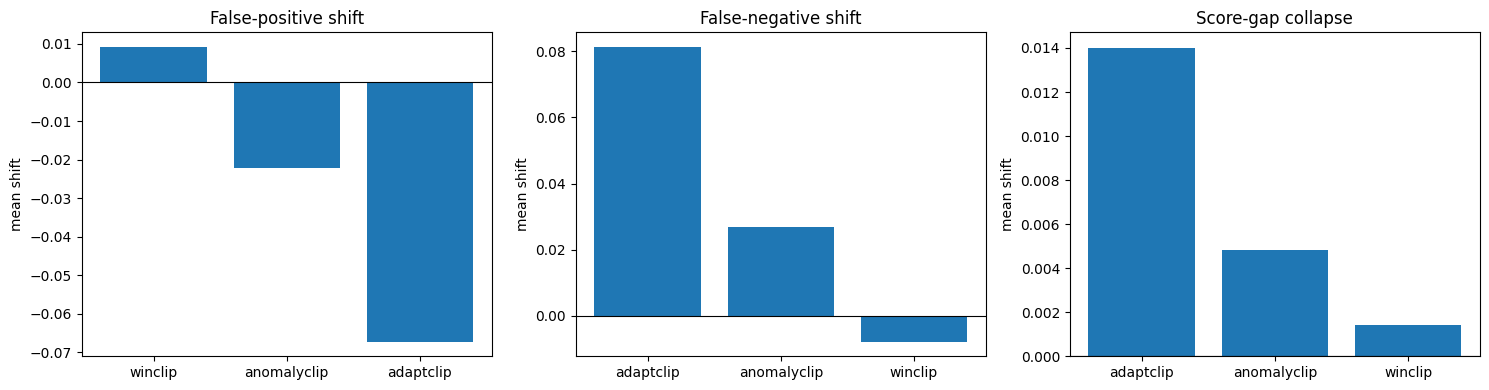

In [132]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(
    axes,
    ['fp_shift', 'fn_shift', 'gap_collapse'],
    ['False-positive shift', 'False-negative shift', 'Score-gap collapse']
):
    tmp = score_shift.groupby('model', as_index=False)[col].mean().sort_values(col, ascending=False)
    ax.bar(tmp['model'], tmp[col])
    ax.set_title(title)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('mean shift')
plt.tight_layout()

### Score Distribution Plot

아래 셀에서 `MODEL / DATASET / TARGET_CLASS`를 바꿔가며 normal/anomaly score 분포가 clean과 corruption에서 어떻게 겹치는지 확인한다.

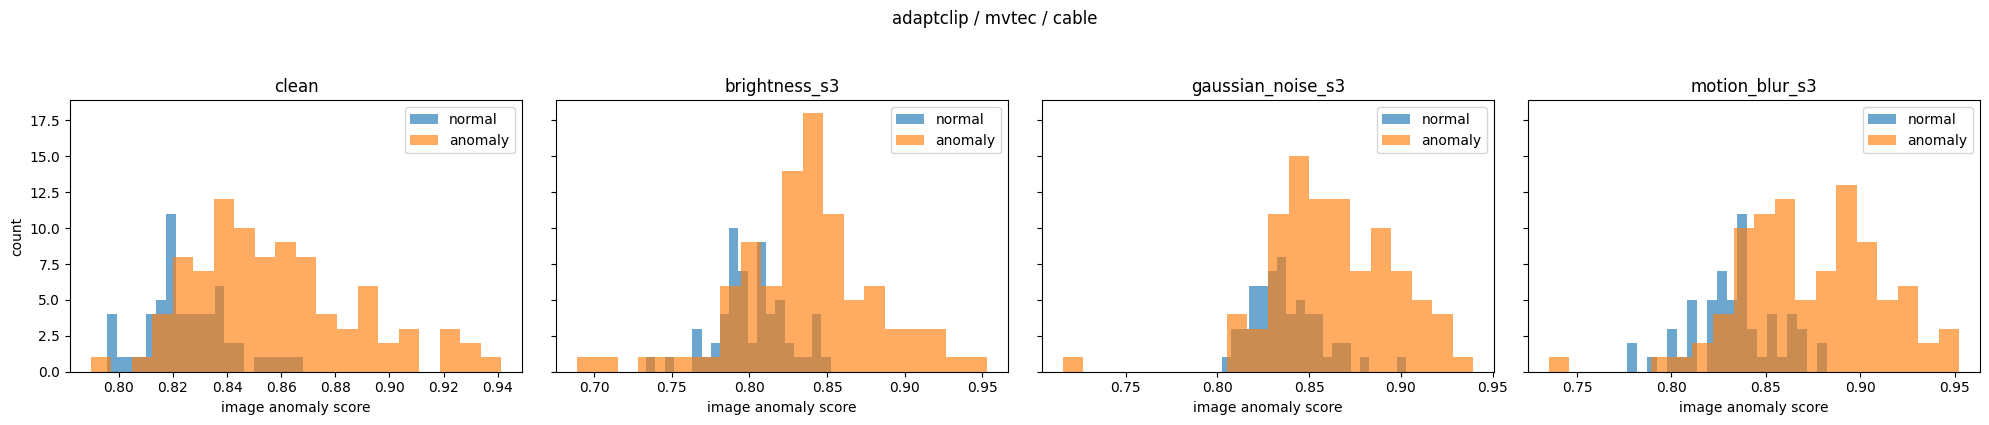

In [133]:
MODEL = 'adaptclip'
DATASET = 'mvtec'
TARGET_CLASS = 'cable'

plot_df = sample_scores[
    (sample_scores['model'] == MODEL) &
    (sample_scores['dataset'] == DATASET) &
    (sample_scores['target_class'].astype(str) == TARGET_CLASS)
].copy()

conditions = ['clean'] + [c for c in sorted(plot_df['condition'].unique()) if c != 'clean']
fig, axes = plt.subplots(1, len(conditions), figsize=(5 * len(conditions), 4), sharey=True)
if len(conditions) == 1:
    axes = [axes]

for ax, condition in zip(axes, conditions):
    tmp = plot_df[plot_df['condition'] == condition]
    ax.hist(tmp[tmp['label'] == 0]['image_score'], bins=20, alpha=0.65, label='normal')
    ax.hist(tmp[tmp['label'] == 1]['image_score'], bins=20, alpha=0.65, label='anomaly')
    ax.set_title(condition)
    ax.set_xlabel('image anomaly score')
    ax.legend()
axes[0].set_ylabel('count')
plt.suptitle(f'{MODEL} / {DATASET} / {TARGET_CLASS}', y=1.05)
plt.tight_layout()

## 6. Pixel-Wise Heatmap Failure Cases

위의 pixel metric table은 정량 분석이고, 여기서는 그 metric drop이 실제 이미지에서 어떤 형태로 나타나는지 정성적으로 확인한다.

중요한 점: heatmap은 전체 증거가 아니라, 위 pixel metric drop을 설명하는 대표 시각화다.

- `low`: per-image pixel AUROC가 낮은 샘플. localization failure 후보
- `high`: 같은 class/condition에서 상대적으로 잘 잡은 샘플

볼 포인트:

- GT defect 영역에 heatmap이 잘 올라오는가?
- defect가 아닌 background/texture에 anomaly response가 올라오는가?
- corruption 후 heatmap이 전체적으로 noisy하게 퍼지는가?


In [134]:
def collect_heatmaps(root=TARGET_ROOT):
    rows = []
    pattern = re.compile(r'auroc_([0-9.]+)_')
    for path in root.glob('*/*/*/*/heatmap/*/*/*/*.png'):
        rel = path.relative_to(root).parts
        model, dataset, target_class, condition = rel[:4]
        group = rel[-2]
        m = pattern.search(path.name)
        pixel_auroc = float(m.group(1)) if m else np.nan
        rows.append({
            'model': model,
            'dataset': dataset,
            'target_class': str(target_class),
            'condition': condition,
            'group': group,
            'pixel_auroc': pixel_auroc,
            'path': path,
        })
    return pd.DataFrame(rows)

heatmaps = collect_heatmaps()
print('heatmaps:', heatmaps.shape)
show(heatmaps.sort_values('pixel_auroc').drop(columns=['path']), 20)

heatmaps: (180, 7)


,model,dataset,target_class,condition,group,pixel_auroc
75,anomalyclip,btad,02,gaussian_noise_s3,low,0.014
76,anomalyclip,btad,02,gaussian_noise_s3,low,0.034
77,anomalyclip,btad,02,gaussian_noise_s3,low,0.041
82,anomalyclip,btad,02,brightness_s3,low,0.045
59,anomalyclip,mvtec,screw,gaussian_noise_s3,low,0.085
58,anomalyclip,mvtec,screw,gaussian_noise_s3,low,0.115
165,adaptclip,btad,02,gaussian_noise_s3,low,0.166
167,adaptclip,btad,02,gaussian_noise_s3,low,0.169
166,adaptclip,btad,02,gaussian_noise_s3,low,0.170
177,adaptclip,btad,02,clean,low,0.206


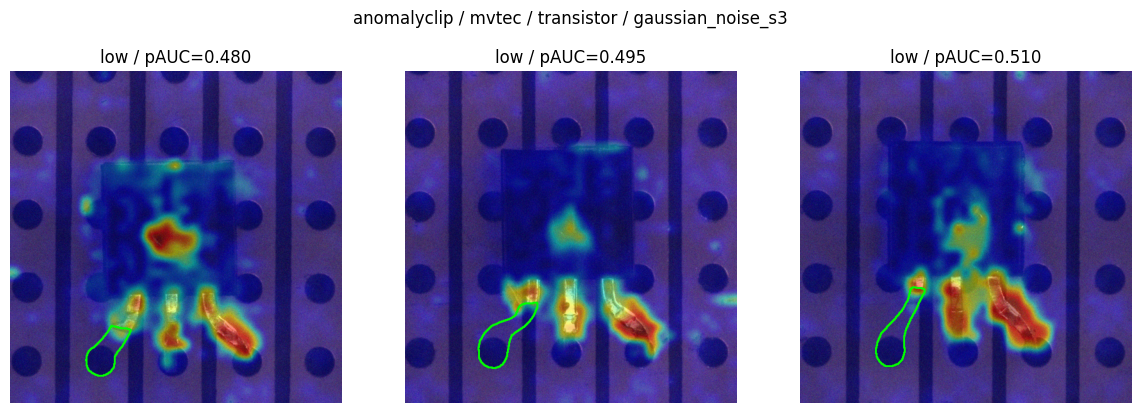

In [135]:
def show_heatmap_gallery(df, model, dataset, target_class, condition, group='low', n=3):
    subset = df[
        (df['model'] == model) &
        (df['dataset'] == dataset) &
        (df['target_class'].astype(str) == str(target_class)) &
        (df['condition'] == condition) &
        (df['group'] == group)
    ].sort_values('pixel_auroc', ascending=(group == 'low')).head(n)
    if subset.empty:
        print('No heatmaps found for selection.')
        return
    fig, axes = plt.subplots(1, len(subset), figsize=(4 * len(subset), 4))
    if len(subset) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, subset.iterrows()):
        img = Image.open(row['path'])
        ax.imshow(img)
        ax.set_title(f"{row['group']} / pAUC={row['pixel_auroc']:.3f}")
        ax.axis('off')
    plt.suptitle(f'{model} / {dataset} / {target_class} / {condition}', y=1.02)
    plt.tight_layout()

show_heatmap_gallery(
    heatmaps,
    model='anomalyclip',
    dataset='mvtec',
    target_class='transistor',
    condition='gaussian_noise_s3',
    group='low',
    n=3,
)

## 7. Figure Candidate Ranking

논문 figure 후보는 다음 세 가지를 같이 보고 고른다.

1. `P-AP_drop`, `P-AUROC_drop`이 큰가? 즉 pixel-wise localization이 정량적으로 무너졌는가?
2. `corrupt_normal_mean`, `corrupt_anomaly_mean`, `gap_collapse`를 봤을 때 image-level confidence도 같이 흔들리는가?
3. `worst_heatmap_pauroc`가 낮고, heatmap에서 failure 형태가 시각적으로 명확한가?


In [136]:
metric_candidates = corruption_pixel_table[
    ['model', 'dataset', 'target_class', 'corruption', 'severity', 'P-AUROC_drop', 'P-AP_drop', 'P-F1max_drop']
].copy()

score_candidates = corruption_score_table[
    [
        'model', 'dataset', 'target_class', 'corruption', 'severity',
        'corrupt_normal_mean', 'corrupt_anomaly_mean',
        'fp_shift', 'fn_shift', 'gap_collapse',
    ]
].copy()

worst_heatmap = (
    heatmaps[heatmaps['group'] == 'low']
    .groupby(['model', 'dataset', 'target_class', 'condition'], as_index=False)['pixel_auroc']
    .min()
    .rename(columns={'pixel_auroc': 'worst_heatmap_pauroc'})
)
worst_heatmap['corruption'] = worst_heatmap['condition'].map(lambda x: condition_to_corruption(x)[0])
worst_heatmap['severity'] = worst_heatmap['condition'].map(lambda x: condition_to_corruption(x)[1])
worst_heatmap = worst_heatmap.drop(columns=['condition'])

candidates = (
    metric_candidates
    .merge(score_candidates, on=['model', 'dataset', 'target_class', 'corruption', 'severity'], how='left')
    .merge(worst_heatmap, on=['model', 'dataset', 'target_class', 'corruption', 'severity'], how='left')
)

show(
    candidates.sort_values(['P-AP_drop', 'gap_collapse'], ascending=False),
    30,
)


,model,dataset,target_class,corruption,severity,P-AUROC_drop,P-AP_drop,P-F1max_drop,corrupt_normal_mean,corrupt_anomaly_mean,fp_shift,fn_shift,gap_collapse,worst_heatmap_pauroc
32,anomalyclip,btad,02,motion_blur,3,0.156,0.281,0.276,0.666,0.747,0.052,0.006,0.058,nan
7,adaptclip,mvtec,pill,gaussian_noise,3,0.058,0.198,0.155,0.652,0.732,0.182,-0.043,0.139,0.678
41,anomalyclip,mvtec,screw,motion_blur,3,0.329,0.174,0.160,0.920,0.925,-0.044,0.056,0.012,nan
38,anomalyclip,mvtec,pill,motion_blur,3,0.040,0.153,0.150,0.901,0.935,-0.073,0.049,-0.025,nan
37,anomalyclip,mvtec,pill,gaussian_noise,3,-0.034,0.149,0.171,0.940,0.958,-0.035,0.026,-0.010,0.471
11,adaptclip,mvtec,screw,motion_blur,3,0.024,0.147,0.151,0.728,0.745,-0.084,0.123,0.038,nan
35,anomalyclip,mvtec,cable,motion_blur,3,0.024,0.124,0.092,0.909,0.954,0.020,-0.018,0.001,nan
2,adaptclip,btad,02,motion_blur,3,0.017,0.115,0.077,0.461,0.622,-0.055,0.113,0.058,nan
34,anomalyclip,mvtec,cable,gaussian_noise,3,0.036,0.112,0.088,0.951,0.967,0.062,-0.031,0.031,0.600
8,adaptclip,mvtec,pill,motion_blur,3,0.021,0.082,0.051,0.351,0.456,-0.119,0.233,0.113,nan


## Takeaway Template

논문/발표에서 결과를 해석할 때는 다음 문장 구조가 가장 안전하다.

1. 전체 benchmark에서 corruption 후 pixel-level metric이 하락한다.
2. 하락은 hard split 및 특정 class에서 더 크게 나타난다.
3. target score 분석에서 일부 class는 normal score 상승 또는 anomaly score 하락으로 score gap이 줄어든다.
4. heatmap 확인 결과, corruption 후 defect region보다 background/texture region에 high anomaly response가 나타나거나, 실제 defect localization이 약해진다.

즉 이 노트북의 결론은 단순히 `성능이 떨어졌다`가 아니라, `corruption이 image-level confidence separation과 pixel-level localization을 동시에 무너뜨린다`로 정리하면 된다.

In [137]:
from pathlib import Path
import pandas as pd

drop_path = Path("../results/corruption_benchmark/summaries/clean_vs_corruption_drop.csv")
if not drop_path.exists():
    drop_path = Path("results/corruption_benchmark/summaries/clean_vs_corruption_drop.csv")

drop = pd.read_csv(drop_path)

metrics = ["I-AUROC", "P-AUROC", "P-AP", "P-F1max"]
drop = drop[drop["metric"].isin(metrics)].copy()

# hard split 중심
hard_drop = drop[drop["split"].eq("hard")].copy()
all_drop = drop[drop["split"].eq("all")].copy()

In [138]:
main_table = (
    hard_drop
    .groupby(["model", "metric"], as_index=False)
    .agg(
        clean=("clean_metric", "mean"),
        corrupt=("corrupt_metric", "mean"),
        drop=("absolute_drop", "mean"),
        relative_drop=("relative_drop", "mean"),
    )
)

main_wide = main_table.pivot(index="model", columns="metric", values="drop")
main_wide = main_wide[["I-AUROC", "P-AUROC", "P-AP", "P-F1max"]]
main_wide.round(3)

metric,I-AUROC,P-AUROC,P-AP,P-F1max
model,,,,
adaptclip,-0.079,0.001,0.004,0.007
anomalyclip,-0.013,0.003,0.002,0.002
winclip,-0.035,-0.019,-0.002,-0.002


In [139]:
win_metric_sensitivity = (
    hard_drop[hard_drop["model"].eq("winclip")]
    .groupby(["corruption", "metric"], as_index=False)
    .agg(drop=("absolute_drop", "mean"))
    .pivot(index="corruption", columns="metric", values="drop")
)

win_metric_sensitivity[["I-AUROC", "P-AUROC", "P-AP", "P-F1max"]].round(3)

metric,I-AUROC,P-AUROC,P-AP,P-F1max
corruption,,,,
brightness,-0.036,0.003,-0.001,-0.001
gaussian_noise,-0.040,-0.057,-0.003,-0.004
motion_blur,-0.028,-0.005,-0.002,-0.000


In [140]:
metrics = ["I-AUROC", "P-AUROC", "P-AP", "P-F1max"]

corruption_metric_drop = (
    hard_drop[hard_drop["metric"].isin(metrics)]
    .groupby(["model", "corruption", "metric"], as_index=False)
    .agg(drop=("absolute_drop", "mean"))
)

table = corruption_metric_drop.pivot_table(
    index=["model", "corruption"],
    columns="metric",
    values="drop"
)

table = table[["I-AUROC", "P-AUROC", "P-AP", "P-F1max"]]
table.round(3)

metric                      I-AUROC  P-AUROC   P-AP  P-F1max
model       corruption                                      
adaptclip   brightness       -0.090   -0.005 -0.003   -0.001
            gaussian_noise   -0.050    0.005  0.007    0.010
            motion_blur      -0.098    0.002  0.009    0.012
anomalyclip brightness       -0.004   -0.003  0.002    0.001
            gaussian_noise   -0.005   -0.002 -0.001   -0.002
            motion_blur      -0.031    0.012  0.006    0.007
winclip     brightness       -0.036    0.003 -0.001   -0.001
            gaussian_noise   -0.040   -0.057 -0.003   -0.004
            motion_blur      -0.028   -0.005 -0.002   -0.000

## Target Hard-Class Drop: Corruption별 / Model별

주의: `corruption_benchmark`의 `split=hard`는 hard **sample** split이라 모든 class가 섞인다.  
여기서는 교수님 코멘트에 맞춰 `target_failure_analysis`에 따로 돌린 **target hard class**만 사용한다.

대상 class:

- MVTec: `transistor`, `pill`, `cable`, `screw`
- VisA: `pcb3`, `pcb2`, `macaroni2`, `macaroni1`, `cashew`
- BTAD: `02`

표 순서:

`corruption -> model -> dataset -> class`

In [ ]:
from pathlib import Path
import pandas as pd

TARGET_ROOT = Path("../results/target_failure_analysis")
if not TARGET_ROOT.exists():
    TARGET_ROOT = Path("results/target_failure_analysis")

MODELS = ["adaptclip", "anomalyclip", "winclip"]
CORRUPTION_ORDER = ["brightness", "gaussian_noise", "motion_blur"]
CONDITIONS = ["clean", "brightness_s3", "gaussian_noise_s3", "motion_blur_s3"]
METRICS = ["I-AUROC", "P-AUROC", "P-AP", "P-F1max"]

TARGET_CLASSES = {
    "mvtec": ["transistor", "pill", "cable", "screw"],
    "visa": ["pcb3", "pcb2", "macaroni2", "macaroni1", "cashew"],
    "btad": ["02"],
}


def condition_to_corruption(condition):
    if condition == "clean":
        return "clean"
    return condition.removesuffix("_s3")


def read_target_metrics(root=TARGET_ROOT):
    rows = []
    for model in MODELS:
        for dataset, classes in TARGET_CLASSES.items():
            for cls in classes:
                for condition in CONDITIONS:
                    metric_path = root / model / dataset / cls / condition / f"class_metrics_{dataset}_10seed_0shot.csv"
                    if not metric_path.exists():
                        continue
                    df = pd.read_csv(metric_path)
                    if df.empty:
                        continue
                    row = df.iloc[0].to_dict()
                    item = {
                        "model": model,
                        "dataset": dataset,
                        "class": str(cls),
                        "condition": condition,
                        "corruption": condition_to_corruption(condition),
                    }
                    for metric in METRICS:
                        item[metric] = row.get(metric)
                    rows.append(item)
    return pd.DataFrame(rows)


target_raw = read_target_metrics()

clean = target_raw[target_raw["condition"].eq("clean")][["model", "dataset", "class"] + METRICS].copy()
clean = clean.rename(columns={metric: f"{metric}_clean" for metric in METRICS})

corrupt = target_raw[~target_raw["condition"].eq("clean")].copy()
target_compact_drop = corrupt.merge(clean, on=["model", "dataset", "class"], how="left")

for metric in METRICS:
    target_compact_drop[f"{metric}_drop"] = target_compact_drop[f"{metric}_clean"] - target_compact_drop[metric]

compact_cols = [
    "corruption",
    "model",
    "dataset",
    "class",
    "I-AUROC_clean",
    "P-AUROC_clean",
    "I-AUROC_drop",
    "P-AUROC_drop",
    "P-AP_drop",
    "P-F1max_drop",
]

target_compact_drop = target_compact_drop[compact_cols].copy()
target_compact_drop["corruption"] = pd.Categorical(target_compact_drop["corruption"], CORRUPTION_ORDER, ordered=True)
target_compact_drop["model"] = pd.Categorical(target_compact_drop["model"], MODELS, ordered=True)
target_compact_drop = target_compact_drop.sort_values(
    ["corruption", "model", "dataset", "class"]
).reset_index(drop=True)

target_compact_drop.round(3)

### Compact Tables by Corruption / Model

각 corruption 아래에 model별 target hard class 표를 바로 띄운다.

In [ ]:
from IPython.display import display, Markdown

compact_display_cols = [
    "dataset",
    "class",
    "I-AUROC_clean",
    "P-AUROC_clean",
    "I-AUROC_drop",
    "P-AUROC_drop",
    "P-AP_drop",
    "P-F1max_drop",
]

for corruption in CORRUPTION_ORDER:
    display(Markdown(f"## {corruption}"))
    for model in MODELS:
        sub = target_compact_drop[
            target_compact_drop["corruption"].eq(corruption)
            & target_compact_drop["model"].eq(model)
        ][compact_display_cols].copy()
        if sub.empty:
            continue
        display(Markdown(f"### {model}"))
        display(sub.round(3))

### Single Target Hard-Class Table Selector

특정 model/corruption 조합만 보고 싶을 때 사용한다.

In [ ]:
MODEL = "winclip"              # adaptclip, anomalyclip, winclip
CORRUPTION = "gaussian_noise"  # brightness, gaussian_noise, motion_blur

selected_target_compact = target_compact_drop[
    target_compact_drop["model"].eq(MODEL)
    & target_compact_drop["corruption"].eq(CORRUPTION)
][compact_display_cols].copy()

selected_target_compact.round(3)

### Save Target Hard-Class Compact Tables

In [ ]:
out_dir = Path("../results/target_failure_analysis/summaries")
if not out_dir.exists():
    out_dir = Path("results/target_failure_analysis/summaries")
out_dir.mkdir(parents=True, exist_ok=True)

target_compact_drop.to_csv(out_dir / "target_hard_class_drop_compact_by_corruption_model.csv", index=False)
for corruption, sub in target_compact_drop.groupby("corruption", observed=True):
    sub.to_csv(out_dir / f"target_hard_class_drop_compact_{corruption}_by_model.csv", index=False)

print("Saved:")
print(out_dir / "target_hard_class_drop_compact_by_corruption_model.csv")
for corruption in CORRUPTION_ORDER:
    print(out_dir / f"target_hard_class_drop_compact_{corruption}_by_model.csv")

## Gaussian Noise: 한눈에 보는 Failure Mode Summary

아래 표는 target hard class 기준으로 gaussian noise에서 무엇이 더 크게 무너지는지 요약한다.

읽는 법:

- `I-AUROC_drop_mean`: image-level separation 하락
- `P-AUROC_drop_mean`: pixel-level localization ranking 하락
- `localization_minus_detection`: 양수면 localization이 detection보다 더 크게 무너짐
- `dominant_failure`: 해당 model의 주요 failure mode

In [ ]:
GAUSSIAN = "gaussian_noise"

gaussian = target_compact_drop[target_compact_drop["corruption"].eq(GAUSSIAN)].copy()

failure_summary = (
    gaussian
    .groupby("model", observed=True)
    .agg(
        I_AUROC_drop_mean=("I-AUROC_drop", "mean"),
        P_AUROC_drop_mean=("P-AUROC_drop", "mean"),
        P_AP_drop_mean=("P-AP_drop", "mean"),
        P_F1max_drop_mean=("P-F1max_drop", "mean"),
        I_AUROC_drop_max=("I-AUROC_drop", "max"),
        P_AUROC_drop_max=("P-AUROC_drop", "max"),
    )
    .reset_index()
)

failure_summary["localization_minus_detection"] = (
    failure_summary["P_AUROC_drop_mean"] - failure_summary["I_AUROC_drop_mean"]
)

failure_summary["dominant_failure"] = failure_summary["localization_minus_detection"].map(
    lambda x: "localization collapse" if x > 0.03 else "image-level separation drop"
)

failure_summary.round(3)

### Gaussian Noise 대표 Evidence: Model별 Worst Classes

각 model에서 `I-AUROC_drop`이 큰 class와 `P-AUROC_drop`이 큰 class를 따로 보여준다.  
이 표를 보면 AdaptCLIP/AnomalyCLIP은 image-level drop이 두드러지고, WinCLIP은 pixel-level drop이 두드러지는지 바로 확인할 수 있다.

In [ ]:
def top_classes_for_metric(df, metric_col, topk=5):
    return (
        df.sort_values(["model", metric_col], ascending=[True, False])
        .groupby("model", observed=True)
        .head(topk)
        [["model", "dataset", "class", "I-AUROC_clean", "P-AUROC_clean", "I-AUROC_drop", "P-AUROC_drop", "P-AP_drop", "P-F1max_drop"]]
        .reset_index(drop=True)
    )

image_drop_evidence = top_classes_for_metric(gaussian, "I-AUROC_drop", topk=5)
localization_drop_evidence = top_classes_for_metric(gaussian, "P-AUROC_drop", topk=5)

print("Image-level separation drop: top classes")
display(image_drop_evidence.round(3))

print("Pixel-level localization drop: top classes")
display(localization_drop_evidence.round(3))

### Gaussian Noise: Presentation Table

발표/보고용으로 바로 쓸 수 있게 핵심 수치만 남긴 표다.

In [ ]:
presentation_summary = failure_summary[[
    "model",
    "I_AUROC_drop_mean",
    "P_AUROC_drop_mean",
    "P_AP_drop_mean",
    "P_F1max_drop_mean",
    "dominant_failure",
]].copy()

presentation_summary = presentation_summary.rename(columns={
    "I_AUROC_drop_mean": "Detection drop (I-AUROC)",
    "P_AUROC_drop_mean": "Localization drop (P-AUROC)",
    "P_AP_drop_mean": "Precise pixel retrieval drop (P-AP)",
    "P_F1max_drop_mean": "Best-threshold mask drop (P-F1max)",
    "dominant_failure": "Main failure mode",
})

presentation_summary.round(3)

### Gaussian Noise Takeaway

Gaussian noise에서 AdaptCLIP과 AnomalyCLIP은 target hard class에서도 `P-AUROC` drop이 작아 localization ranking은 비교적 유지된다.  
반면 `I-AUROC` drop이 더 크게 나타나 image-level separation이 먼저 흔들린다.  
WinCLIP은 `screw`, `pill`, `pcb3` 등에서 `P-AUROC` drop이 커져, gaussian noise에 의해 pixel-level localization이 더 직접적으로 붕괴되는 경향을 보인다.

한 줄 요약: **Gaussian noise에서는 최신 모델은 detection이 흔들리고, WinCLIP은 localization이 더 가파르게 무너진다.**

In [ ]:
out_dir = Path("../results/target_failure_analysis/summaries")
if not out_dir.exists():
    out_dir = Path("results/target_failure_analysis/summaries")
out_dir.mkdir(parents=True, exist_ok=True)

failure_summary.to_csv(out_dir / "gaussian_noise_failure_mode_summary.csv", index=False)
image_drop_evidence.to_csv(out_dir / "gaussian_noise_image_drop_evidence.csv", index=False)
localization_drop_evidence.to_csv(out_dir / "gaussian_noise_localization_drop_evidence.csv", index=False)
presentation_summary.to_csv(out_dir / "gaussian_noise_presentation_summary.csv", index=False)

print("Saved gaussian-noise summary tables to", out_dir)

## Presentation Figures: Gaussian Noise

발표용 그림 3개를 만든다.

1. **Model별 평균 drop bar plot**: detection vs localization이 한눈에 보임.
2. **Hard class별 P-AUROC drop heatmap**: 어떤 class/model에서 localization이 흔들리는지 보임.
3. **WinCLIP class별 drop bar plot**: WinCLIP의 class-dependent instability를 강조.

부호 기준: `drop = clean - corrupted` 이므로, **양수는 성능 하락**, **음수는 corruption 후 성능 증가**다.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plot_dir = Path("../results/target_failure_analysis/summaries/plots")
if not plot_dir.exists():
    plot_dir = Path("results/target_failure_analysis/summaries/plots")
plot_dir.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 240,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

MODEL_COLORS = {
    "adaptclip": "#2F6BFF",
    "anomalyclip": "#20A67A",
    "winclip": "#D64A3A",
}

metric_labels = {
    "Detection drop (I-AUROC)": "I-AUROC",
    "Localization drop (P-AUROC)": "P-AUROC",
    "Precise pixel retrieval drop (P-AP)": "P-AP",
    "Best-threshold mask drop (P-F1max)": "P-F1max",
}

# 1) Model-level grouped bar: detection vs localization metrics
fig, ax = plt.subplots(figsize=(9.5, 4.6))
plot_df = presentation_summary.copy()
metric_cols = list(metric_labels.keys())
x = np.arange(len(metric_cols))
width = 0.23

for offset, model in zip([-width, 0, width], MODELS):
    row = plot_df[plot_df["model"].eq(model)]
    if row.empty:
        continue
    vals = row[metric_cols].iloc[0].to_numpy(dtype=float)
    ax.bar(x + offset, vals, width=width, label=model, color=MODEL_COLORS.get(model))

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([metric_labels[col] for col in metric_cols])
ax.set_ylabel("Mean drop (clean - gaussian noise)")
ax.set_title("Gaussian Noise: Mean Metric Drop on Target Hard Classes")
ax.legend(frameon=False, ncol=3, loc="upper right")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(plot_dir / "gaussian_metric_drop_grouped_bar.png", bbox_inches="tight")
plt.show()

# 2) P-AUROC drop heatmap: rows=dataset/class, cols=model
heat = gaussian.pivot_table(
    index=["dataset", "class"],
    columns="model",
    values="P-AUROC_drop",
    aggfunc="mean",
)
heat = heat[[m for m in MODELS if m in heat.columns]]
row_labels = [f"{dataset}/{cls}" for dataset, cls in heat.index]

fig, ax = plt.subplots(figsize=(7.5, max(4.5, 0.38 * len(row_labels))))
im = ax.imshow(heat.to_numpy(dtype=float), cmap="RdBu_r", vmin=-0.25, vmax=0.25, aspect="auto")
ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels(heat.columns)
ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels)
ax.set_title("Gaussian Noise: P-AUROC Drop by Target Hard Class")

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.iloc[i, j]
        if np.isfinite(val):
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", color="black", fontsize=8)

cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
cbar.set_label("P-AUROC drop")
fig.tight_layout()
fig.savefig(plot_dir / "gaussian_pauroc_drop_heatmap.png", bbox_inches="tight")
plt.show()

# 3) WinCLIP per-class bar plot: I-AUROC vs P-AUROC drop
win = gaussian[gaussian["model"].eq("winclip")].copy()
win["label"] = win["dataset"].astype(str) + "/" + win["class"].astype(str)
win = win.sort_values("P-AUROC_drop", ascending=True)

y = np.arange(len(win))
fig, ax = plt.subplots(figsize=(8.2, max(4.5, 0.42 * len(win))))
ax.barh(y - 0.18, win["I-AUROC_drop"], height=0.34, label="I-AUROC drop", color="#7A7A7A")
ax.barh(y + 0.18, win["P-AUROC_drop"], height=0.34, label="P-AUROC drop", color=MODEL_COLORS["winclip"])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels(win["label"])
ax.set_xlabel("Drop (clean - gaussian noise)")
ax.set_title("WinCLIP under Gaussian Noise: Detection vs Localization Drop")
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(plot_dir / "gaussian_winclip_detection_vs_localization_drop.png", bbox_inches="tight")
plt.show()

print("Saved plots to:", plot_dir)

### Slide Interpretation

- Grouped bar plot: 최신 모델은 `I-AUROC` drop이 상대적으로 크고 `P-AUROC` drop은 작다.
- P-AUROC heatmap: localization drop이 class/model별로 어떻게 다른지 한눈에 보인다.
- WinCLIP bar plot: WinCLIP은 gaussian noise에서 class-dependent하게 흔들리며, 일부 class에서는 localization drop이 크게 나타난다.